# Hafta 6 · Ders 11 — Sıfırdan Bir Evrişim Katmanı

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Nihayet *tasarlanmış* filtrelerden *öğrenilmiş* olanlara geçiyoruz. Hafta 2–3'te kenarları ve
bulanıklıkları çıkarmak için çekirdekleri elle seçtik (kutu, Gauss, Sobel). Bir **evrişimli sinir ağı
(CNN)** tam olarak aynı kaydırmalı-pencere işlemini korur ama gradyan inişi ile **çekirdek
ağırlıklarını veriden öğrenir**.

Ağırlıkları öğrenmek için gradyanlara ihtiyacımız var, bu yüzden bu notebook bir evrişim katmanını
ileri geçiş **ve** geri geçişle birlikte inşa ediyor — saf NumPy ile, böylece hiçbir şey gizli değil.
Analitik gradyanları sayısal olanlara karşı doğruluyor, ReLU ve maks havuzlama (max-pooling)
ekliyoruz ve katmanın bilinen bir filtreyi *öğrenebileceğini* doğruluyoruz. Bu, mekanik çekirdektir;
sonraki notebook bir ağı baştan sona eğitir (ölçek için bir PyTorch karşılığıyla).

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, check

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. İleri geçiş: evrişim (aslında çapraz korelasyon)

Bir evrişim katmanı, her öğrenilebilir çekirdeği giriş üzerinde kaydırır ve ağırlıklı bir toplam artı
bir yanlılık (bias) hesaplar. Derin öğrenme buna "evrişim" der ama çekirdeği **çevirmez** — bu yüzden
teknik olarak Ders 3'teki *çapraz korelasyondur*. Tek bir giriş kanalı ve $k\\times k$ boyutunda tek
bir $W$ filtresi için:

$$ Y[i, j] = b + \\sum_{a=0}^{k-1}\\sum_{b'=0}^{k-1} X[i+a,\\, j+b']\\;W[a, b'] $$

İlk önce açık döngülerle (hız yerine açıklık) "valid" dolgulu (kenar yok) olarak uyguluyoruz.

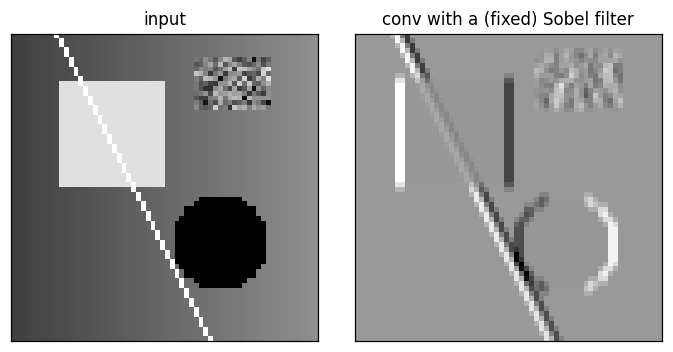

output shape: (62, 62)  (valid padding shrinks by k-1)


In [2]:
def conv_forward(X, W, b):
    "X: (H, W_in)  çekirdek W: (k, k)  yanlılık b: skaler  ->  Y: (H-k+1, W_in-k+1)."
    H, Wd = X.shape
    k = W.shape[0]
    oh, ow = H - k + 1, Wd - k + 1
    Y = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            Y[i, j] = np.sum(X[i:i+k, j:j+k] * W) + b
    return Y

img = sample_gray(64)
sobel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float)
Y = conv_forward(img, sobel, 0.0)
show_row([img, Y], ["giriş", "(sabit) Sobel filtresiyle evrişim"])
plt.show()
print("çıkış biçimi:", Y.shape, " (valid dolgu k-1 kadar küçültür)")

## 2. Geri geçiş: zincir kuralıyla gradyanlar

Eğitim, yukarı akış gradyanı $\\partial L/\\partial Y$ (ona `dY` diyelim) verildiğinde
$\\partial L/\\partial W$, $\\partial L/\\partial b$ ve $\\partial L/\\partial X$'i ister. Her biri
ileri toplamda zincir kuralından gelir:

- $\\dfrac{\\partial L}{\\partial W[a,b']} = \\sum_{i,j} dY[i,j]\\,X[i+a, j+b']$  (girişi dY ile korele et)
- $\\dfrac{\\partial L}{\\partial b} = \\sum_{i,j} dY[i,j]$
- $\\dfrac{\\partial L}{\\partial X}$ = `dY`'nin çevrilmiş çekirdekle **tam** evrişimi (gradyan geri yayılır)

Bu üç formül bir CNN'in tüm öğrenme mekanizmasıdır.

In [3]:
def conv_backward(dY, X, W):
    k = W.shape[0]
    oh, ow = dY.shape
    dW = np.zeros_like(W)
    dX = np.zeros_like(X)
    db = dY.sum()
    for i in range(oh):
        for j in range(ow):
            dW += dY[i, j] * X[i:i+k, j:j+k]        # ağırlık gradyanını biriktir
            dX[i:i+k, j:j+k] += dY[i, j] * W        # giriş gradyanını dağıt
    return dX, dW, db

# hızlı biçim sağlaması
dY = np.ones_like(Y)
dX, dW, db = conv_backward(dY, img, sobel)
print("dX:", dX.shape, " dW:", dW.shape, " db:", round(db, 2))

dX: (64, 64)  dW: (3, 3)  db: 3844.0


## 3. Gradyan kontrolü — pazarlık edilemez doğruluk testi

Elle türetilmiş gradyanları biraz yanlış yapmak kolaydır. Altın standart test, onları sonlu farklarla
hesaplanan bir **sayısal gradyana** karşı karşılaştırır: bir parametreyi $\\pm\\varepsilon$ kadar
sars, kaybın nasıl değiştiğini ölç ve analitik değerle eşleştiğini kontrol et. Geri yayılımdan gelen
`dW`, sayısal kestirimle eşleşirse, katman doğrudur.

In [4]:
rng = np.random.default_rng(0)
X = rng.standard_normal((8, 8))
W = rng.standard_normal((3, 3))
b = 0.5

# skaler kayıp: çıktıların karelerinin toplamı (keyfi ama türevlenebilir)
def loss_fn(X, W, b):
    return 0.5 * np.sum(conv_forward(X, W, b) ** 2)

# geri yayılım yoluyla analitik gradyan: bu kayıp için dL/dY = Y
Y = conv_forward(X, W, b)
dX_a, dW_a, db_a = conv_backward(Y, X, W)

# W için sayısal gradyan
eps = 1e-5
dW_n = np.zeros_like(W)
for a in range(3):
    for bb in range(3):
        Wp = W.copy(); Wp[a, bb] += eps
        Wm = W.copy(); Wm[a, bb] -= eps
        dW_n[a, bb] = (loss_fn(X, Wp, b) - loss_fn(X, Wm, b)) / (2 * eps)

check("analitik dW vs sayısal dW", dW_a, dW_n, atol=1e-5)
# b için sayısal gradyan
db_n = (loss_fn(X, W, b+eps) - loss_fn(X, W, b-eps)) / (2*eps)
check("analitik db vs sayısal db", db_a, db_n, atol=1e-5)

[PASS] analytic dW vs numerical dW        max|Δ| = 2.35e-09
[PASS] analytic db vs numerical db        max|Δ| = 5.33e-11


True

## 4. ReLU ve maks havuzlama (max-pooling)

İki yapı bloğu daha bir CNN aşamasını tamamlar:

- **ReLU** $f(x) = \\max(0, x)$ — doğrusal olmayanlık enjekte eden bir nokta işlemi (Ders 2!).
  Gradyanı, giriş pozitifse 1, aksi halde 0'dır.
- **Maks havuzlama**, her pencerede maksimumu tutarak alt örnekler ve küçük-kaymaya değişmezlik verir.
  Gradyanı tamamen maksimum olan elemana yönlendirilir.

Her ikisinin de basit ileri ve geri geçişleri vardır.

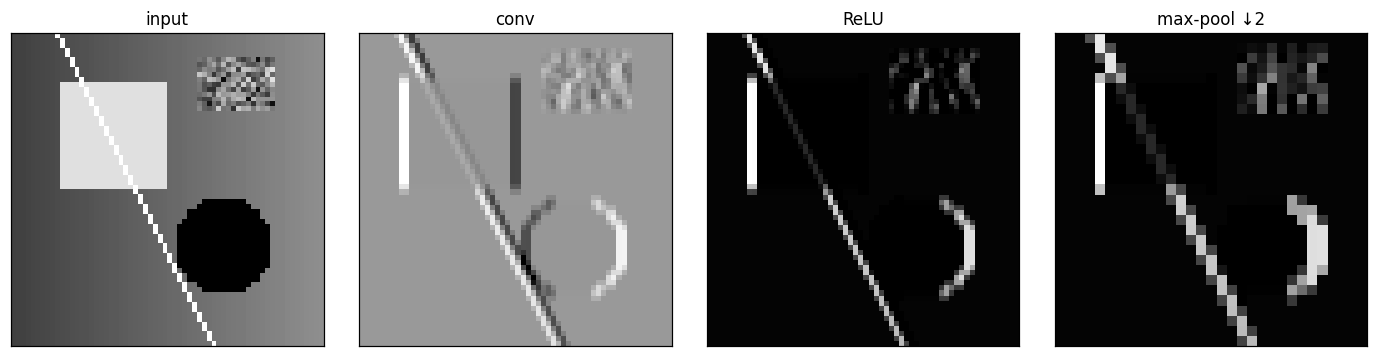

In [5]:
def relu_forward(X):
    return np.maximum(0, X), (X > 0)

def relu_backward(dY, mask):
    return dY * mask

def maxpool_forward(X, size=2):
    H, W = X.shape
    oh, ow = H // size, W // size
    Y = np.zeros((oh, ow)); argmax = {}
    for i in range(oh):
        for j in range(ow):
            win = X[i*size:(i+1)*size, j*size:(j+1)*size]
            Y[i, j] = win.max()
            a = np.unravel_index(win.argmax(), win.shape)
            argmax[(i, j)] = (i*size + a[0], j*size + a[1])
    return Y, argmax

def maxpool_backward(dY, argmax, X_shape, size=2):
    dX = np.zeros(X_shape)
    for (i, j), (yi, xi) in argmax.items():
        dX[yi, xi] += dY[i, j]          # gradyan yalnızca maks konumuna akar
    return dX

# ileri zinciri göster: evrişim → ReLU → havuzlama
feat = conv_forward(img, sobel, 0.0)
relu, mask = relu_forward(feat)
pooled, _ = maxpool_forward(relu, 2)
show_row([img, feat, relu, pooled], ["giriş", "evrişim", "ReLU", "maks-havuzlama ↓2"])
plt.show()

## 5. Gradyan inişiyle bir filtre öğrenme

Ödül: katman *öğrenebilir mi*? Küçük bir denetimli görev kuruyoruz — bir giriş görüntüsü ve gizli bir
Sobel filtresinin ürettiği **hedef çıktı** verildiğinde, gradyan inişi rastgele ağırlıklardan başlayarak
o filtreyi geri kazanabilir mi? Öğrenilen çekirdek Sobel'e yakınsarsa, ileri+geri mekanizmamız
gerçekten öğreniyor demektir.

final loss: 2.18e-03


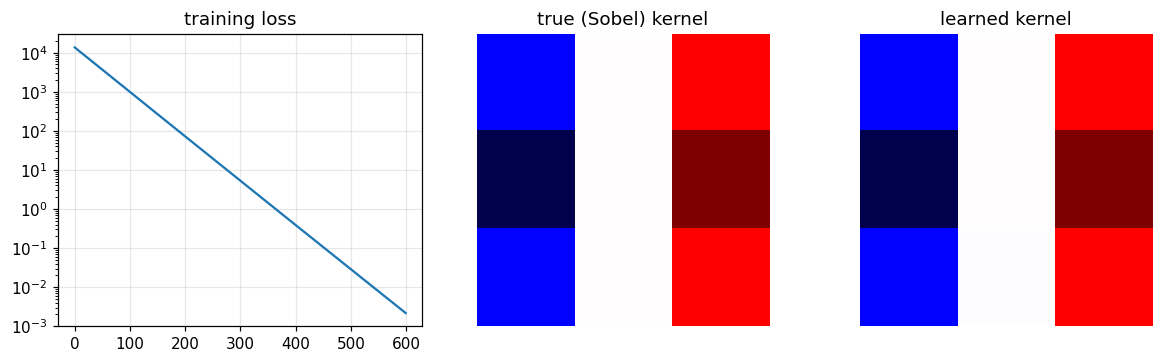

[PASS] learned kernel ≈ Sobel             max|Δ| = 8.02e-04


True

In [6]:
target_kernel = sobel.copy()
# hedef filtrenin tamamen belirlenmesi için birkaç rastgele eğitim görüntüsü kullan
# (tek bir görüntü çekirdeği yalnızca gradyanlarının olduğu yerlerde kısıtlar)
train_imgs = [rng.standard_normal((20, 20)) for _ in range(8)]
targets = [conv_forward(im, target_kernel, 0.0) for im in train_imgs]

W = rng.standard_normal((3, 3)) * 0.1               # rastgele başlatma
b = 0.0
lr = 2e-3 / train_imgs[0].size
losses = []
for step in range(600):
    total = 0.0
    for im, tgt in zip(train_imgs, targets):
        Y = conv_forward(im, W, b)
        diff = Y - tgt
        total += 0.5 * np.sum(diff**2)
        dX, dW, db = conv_backward(diff, im, W)      # dL/dY = (Y - hedef)
        W -= lr * dW
        b -= lr * db
    losses.append(total)

print("nihai kayıp:", f"{losses[-1]:.2e}")
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
axes[0].plot(losses, color="C0"); axes[0].set_yscale("log"); axes[0].set_title("eğitim kaybı"); axes[0].grid(alpha=0.3)
axes[1].imshow(target_kernel, cmap="seismic", vmin=-2, vmax=2); axes[1].set_title("gerçek (Sobel) çekirdek"); axes[1].axis("off")
axes[2].imshow(W, cmap="seismic", vmin=-2, vmax=2); axes[2].set_title("öğrenilen çekirdek"); axes[2].axis("off")
plt.tight_layout(); plt.show()
check("öğrenilen çekirdek ≈ Sobel", W, target_kernel, atol=0.05)

## 6. Bunun modern görüde nerede karşımıza çıktığı

- **Bu bir CNN katmanıdır.** Her çerçevenin `Conv2d`'si tam olarak bu ileri geçişi ve bu üç gradyanı
  çalıştırır — sadece vektörleştirilmiş (genellikle `im2col` veya FFT ile), yığınlanmış ve çok
  kanallı olarak. Sonraki notebook'ta optimize edilmiş versiyonu kullanacağız.
- **Öğrenilmiş kenar filtreleri.** Bir evrişim katmanının Sobel'i öğrenebilmesi, eğitilmiş görü ağlarının
  ilk katmanının güvenilir biçimde yönelimli kenar dedektörleri içermesinin nedenidir — ağ, Hafta
  2–3'ü veriden keşfeder.
- **ReLU ve havuzlama** gerçek ağlarda değişmez; PyTorch/JAX'taki otomatik türev, elle yazdığımız
  geri geçişleri otomatikleştirir.

Önizleme: öğrenilmiş filtreleri yığmak bir öznitelik hiyerarşisi inşa eder — kenarlar → dokular →
parçalar → nesneler.

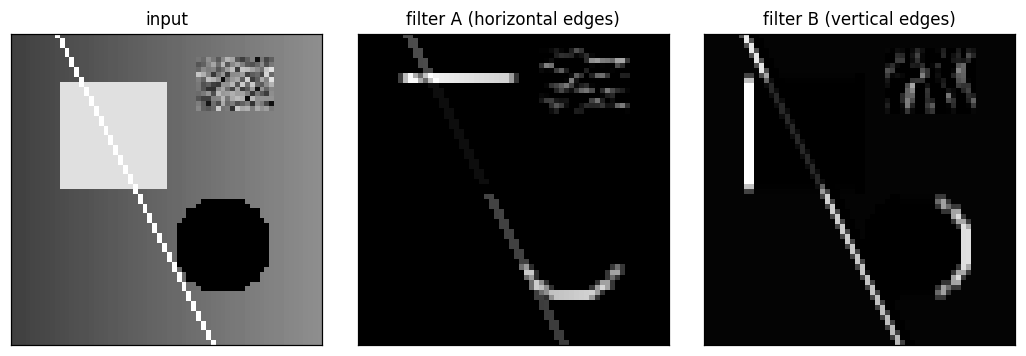

A real conv layer has many such filters, all learned jointly — the start of a feature hierarchy.


In [7]:
# farklı yönelimlere yanıt veren 2-filtreli "banka" göster (öğrenilmiş bir katmanın yapacağı gibi)
horiz = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float)
vert  = sobel
fh = np.maximum(0, conv_forward(img, horiz, 0))
fv = np.maximum(0, conv_forward(img, vert, 0))
show_row([img, fh, fv], ["giriş", "filtre A (yatay kenarlar)", "filtre B (dikey kenarlar)"])
plt.show()
print("Gerçek bir evrişim katmanında böyle birçok filtre vardır, hepsi birlikte öğrenilir — bir öznitelik hiyerarşisinin başlangıcı.")

## Alıştırmalar

1. **Gradyan kontrolü dX.** Sayısal gradyan kontrolünü `dX` giriş gradyanına genişlet ve geri yayılımla eşleştiğini doğrula.
2. **Adım (stride).** `conv_forward`'a bir adım parametresi ekle (adım > 1) ve geri geçişin nasıl değiştiğini çözümle.
3. **Ortalama havuzlama.** Ortalama-havuzlamanın ileri ve geri geçişini uygula. Gradyanı maks-havuzlamanınkinden nasıl farklıdır?

In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. dX için sayısal kontrol
X = rng.standard_normal((6, 6)); W = rng.standard_normal((3, 3)); b = 0.0
Y = conv_forward(X, W, b)
dX_a, _, _ = conv_backward(Y, X, W)
dX_n = np.zeros_like(X)
eps = 1e-5
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Xp = X.copy(); Xp[i,j] += eps; Xm = X.copy(); Xm[i,j] -= eps
        dX_n[i,j] = (0.5*np.sum(conv_forward(Xp,W,b)**2) - 0.5*np.sum(conv_forward(Xm,W,b)**2))/(2*eps)
check("analitik dX vs sayısal dX", dX_a, dX_n, atol=1e-5)

# 3. ortalama havuzlama gradyanı tüm pencere elemanlarına eşit olarak yayar (yalnızca maks değil)
print("\nmaks-havuz gradyanı → pencere başına 1 eleman; ort-havuz gradyanı → her elemana 1/n.")

[PASS] analytic dX vs numerical dX        max|Δ| = 7.90e-10

max-pool gradient → 1 element per window; avg-pool gradient → 1/n to each element.


## Özet ve sırada ne var

Bir evrişim katmanı, **öğrenilebilir** ağırlıklara sahip Ders 3'teki kaydırma penceresidir. İleri geçişi
ağırlıklı bir komşuluk toplamıdır; geri geçişi üç zincir-kuralı formülüdür (sayısal gradyanlara karşı
doğrulanmış). ReLU, havuzlama ve gradyan inişiyle birlikte katman filtreleri *öğrenir* — Sobel'i sıfırdan
geri kazanmasını izledik.

**Sırada — `12_training_a_cnn_capstone.ipynb`:** final. Bu katmanları küçük bir CNN'e yığıyor, onu gerçek
rakam görüntülerini baştan sona sınıflandırmak için eğitiyor, öğrenilen filtreleri görselleştiriyor ve
aynı mimariyi ölçeklendiren bir PyTorch versiyonu sağlıyoruz — tek pikselden eğitilmiş bir tanıyıcıya
döngüyü kapatıyoruz.

---
*Bilgisayarlı Görü · Hafta 6 · Ders 11*